In [1]:
import pymaster as nmt
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

These notebooks aim to provide a comprehensive review of the functionality implemented in NaMaster. No rigorous mathematical derivations of any statements made will be provided, and users are referred to the references below for further details:
- **A19**. The original NaMaster paper (Alonso et al. 2019 https://arxiv.org/abs/1809.09603).
- **G19**. Garcia-Garcia et al. 2019 (https://arxiv.org/abs/1906.11765), which introduces the basic approximation used by NaMaster to estimate covariance matrix.
- **N20**. Nicola et al. 2020 (https://arxiv.org/abs/2010.09717), which refined these approximations and described in detail the procedure to estimate cosmic shear power spectra.
- **W24**. Wolz et al. 2024 (https://arxiv.org/abs/2407.21013), which introduced the formalism for catalog-based $C_\ell$s.
- **A24**. Alonso 2024 (https://arxiv.org/abs/2410.07077), which generalised the estimator to anisotropic weights.
- **C25**. Cornish et al. 2025 (https://arxiv.org/abs/2510.19912), which developed deprojection techniques for catalog-based $C_\ell$s.
- **W26**. Wolz et al. 2026 (https://arxiv.org/abs/2607.14843), which presented a method for covariances of catalog-based $C_\ell$s.

# 2 Spin-$s$ fields <a class="anchor" id="S2"></a>
This tutorial introduces non-scalar fields and their treatment in NaMaster. For a thorough introduction to the treatment of fields with spin, representing vectors and other non-invariant quantities under rotations in cosmology and astrophysics, I recommend the following references: [Goldberg et al. 1967](https://ui.adsabs.harvard.edu/abs/1967JMP.....8.2155G/abstract), [Newman & Penrose 1966](https://ui.adsabs.harvard.edu/abs/1966JMP.....7..863N/abstract), and [Lewis et al. 2001](https://arxiv.org/abs/astro-ph/0106536).

Spin-$s$ quantities are represented by a pair of sky maps, which we will refer to as $(Q(\hat{\bf n}),U(\hat{\bf n}))$, mimicking the notation used to describe the CMB polarisation Stokes parameters. Under rotations by an angle $\psi$ around the pole, these fields transform together as
$$
  (Q+iU)\longrightarrow e^{is\psi}(Q+iU).
$$
Generally, spin-$s$ fields can be described in terms of a scalar and a pseudo scalar field, labelled $E(\hat{\bf n})$ and $B(\hat{\bf n})$ respectively, to which they are related via spin-$s$ spherical harmonic transforms. In harmonic space, it is thus common to describe spin-$s$ fields in terms of $E_{\ell m}$ and $B_{\ell m}$. For this reason, when estimating power spectra of spin-$s$ fields, we must consider the 4 potentially distinct combinations $(C^{EE}_\ell,C^{EB}_\ell,C^{BE}_\ell,C^{BB}_\ell)$. Likewise, when dealing with cross-correlations between a spin-$0$ (scalar) field $a$ and a spin-$s$ field, two $C_\ell$ must be considered $(C^{aE}_\ell, C^{aB}_\ell)$.

As in the case of spin-$0$ field, the presence of a sky mask will lead to the mixing of different harmonic $(\ell, m)$ modes. For spin-$s$ fields, this will be also accompanied by a coupling of $E$ and $B$ modes, which must be taken into account and corrected. In the PCL formalism, this coupling is completely dependent on the masks involved, and not on the signal, and can be estimated analytically. As such, the mode-coupling matrix now has up to $4\times 4$ sub-blocks of potential interest, characterising the coupling between the 4 power spectra above (replace 2 by 4 if dealing with scalar-spin cross-correlations). More in detail, the sub-blocks involving a coupling between power spectra with different parity (e.g. $C_\ell^{EB}$ and $C_\ell^{BB}$, or $C_\ell^{aE}$ and $C_\ell^{aB}$) are zero by construction, since a local transformation does not modify the field's transformation properties under parity.

Although $E\leftrightarrow B$ mixing can be taken into account by the standard PCL algorithm at the power specrum level, it is desirable, in certain situations, to mitigate this mode leakage at the map level. A typical example is the case of fields with a strong $E$-$B$ asymmetry, in which the large variance of the $E$-mode field can dominate the uncertainties of the $B$-mode power spectrum in the presence of leakage. To deal with these situations, $E$- and $B$-mode purification techniques have been developed and can also be used in NaMaster.

The code below demonstrates the treatment of spin-$s$ fields in NaMaster.

# Table of contents

* [2.1 Spin-$s$ maps and fields](#Ss2.1)
* [2.2 Pseudo-$C_\ell$s](#Ss2.2)
* [2.3 Mode-coupling matrices](#Ss2.3)
* [2.4 Unbiased estimator](#Ss2.4)
* [2.5 Purification](#Ss2.5)

## 2.1 Spin-$s$ maps and fields <a class="anchor" id="Ss2.1"></a>
The code below generates Gaussian realisations of a spin-0 field and a spin-2 field. We will assume the spin-0 field and the $E$-mode of the spin-2 field both follow the same power spectrum $C^{aa}_\ell=C_\ell^{EE} = 1/(\ell+10)$. Furthermore, we will assume the spin-2 $B$-mode to be a factor 10 smaller in amplitude (i.e. $C_\ell^{BB}=0.01C_\ell^{EE}$), and we will assume a 50% correlation between the scalar field and the $E$ mode (i.e. $C_\ell^{aE}=0.5\sqrt{C_\ell^{aa}C_\ell^{EE}}$). All parity-odd spectra ($C_\ell^{aB}$ and $C_\ell^{EB}$) are set to zero.

We will consider a similar mask to that used in Tutorial 1. However, since we need to be a bit more careful about apodisation (see [Section 2.6](#Ss2.6)), we will generate it at high-resolution and only downgrade it after apodisation. We will also use a more aggressive apodisation kernel.

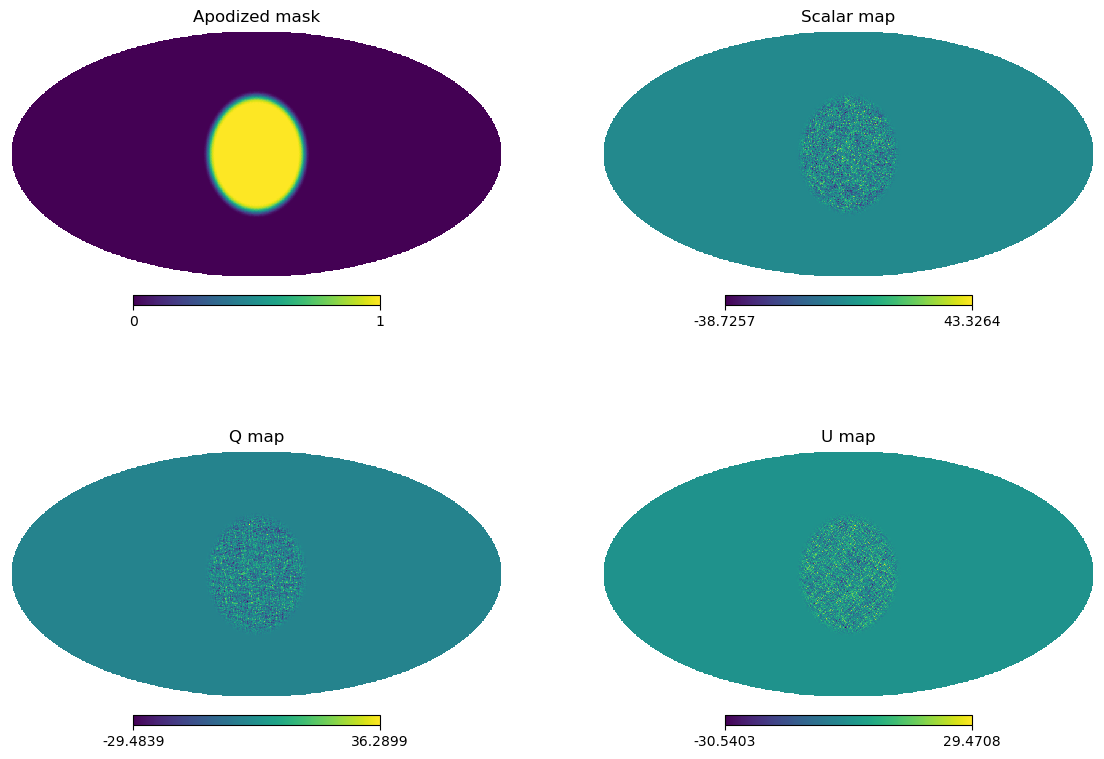

In [2]:
# HEALPix resolution parameter
nside = 256
npix = hp.nside2npix(nside)

# Range of ells to explore and input power spectrum
ls = np.arange(3*nside)
cl_aa = cl_ee = 1/(ls+10)
cl_bb = 0.01*cl_ee
cl_ae = 0.5*cl_aa

# Simulator
def gen_sim():
    alm, Elm, Blm = hp.synalm([cl_aa, cl_ee, cl_bb, cl_ae, 0*cl_ae, 0*cl_ae],
                              lmax=3*nside-1, new=True)
    Q, U = hp.alm2map_spin([Elm, Blm], nside, 2, 3*nside-1)
    a = hp.alm2map(alm, nside)
    return a, Q, U

# Binary mask
nside_hi = 512
npix_hi = hp.nside2npix(nside_hi)
mask_binary = np.zeros(npix_hi)
mask_binary[hp.query_disc(nside_hi, [1, 0, 0], np.radians(40))] = 1

# Apodised mask
# We use a 5-degree "C1" apodisation (see Grain et al. 2009).
mask = hp.ud_grade(nmt.mask_apodization(mask_binary, 10.0, "C1"), nside_out=nside)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plt.axes(axes[0][0])
hp.mollview(mask, title='Apodized mask', hold=True)

mpa, mpQ, mpU = gen_sim()

# To generate a spin-s field in NaMaster, simply pass a list of 2 maps
# as the corresponding map. Note that, if you do not specify the field's
# spin, it will be taken to be 0 (if only one map is passed) or 2 (if
# two maps are passed).
f0 = nmt.NmtField(mask, [mpa], n_iter=0)
f2 = nmt.NmtField(mask, [mpQ, mpU], n_iter=0)
# The next line is equivalent to the one above
f2 = nmt.NmtField(mask, [mpQ, mpU], spin=2, n_iter=0)
plt.axes(axes[0][1])
hp.mollview(f0.get_maps()[0], title='Scalar map', hold=True)
plt.axes(axes[1][0])
hp.mollview(f2.get_maps()[0], title='Q map', hold=True)
plt.axes(axes[1][1])
hp.mollview(f2.get_maps()[1], title='U map', hold=True)

The pattern of "+" in Q and "x" in U you that is evident in the maps is an unequivocal signature that our field is $E$-mode dominated.

## 2.2 Pseudo-$C_\ell$s <a class="anchor" id="Ss2.2"></a>
After creating fields, you can estimate their pseudo-$C_\ell$s just like you did for scalar fields. Note the ordering used by NaMaster.

Notice that, while the $f_{\rm sky}$ correction we saw in Tutorial 1 does the job (more or less) for the scalar and $E$-mode fields, it clearly fails to recover the right $B$-mode spectrum at low $\ell$. This is because, while the correction accounts for the loss of modes due to masking, it does not correct the leakage of large-amplitude $E$-modes into the masked $B$-mode map.

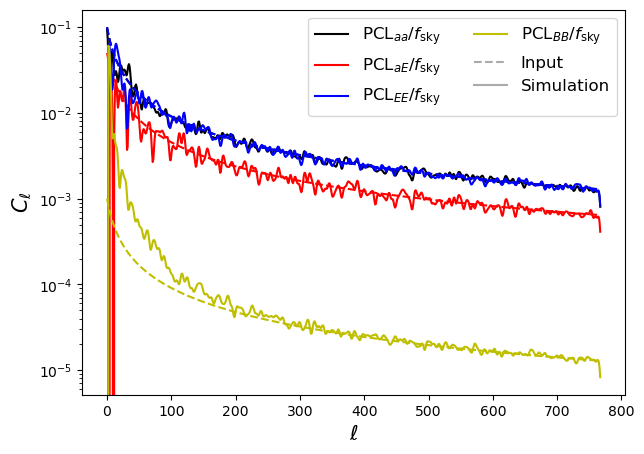

In [3]:
pcl_aa = nmt.compute_coupled_cell(f0, f0)[0]
pcl_aE, pcl_aB = nmt.compute_coupled_cell(f0, f2)
pcl_EE, pcl_EB, pcl_BE, pcl_BB = nmt.compute_coupled_cell(f2, f2)
fsky = np.mean(f0.get_mask()**2)

plt.figure(figsize=(7, 5))
plt.plot(ls, cl_aa, 'k--')
plt.plot(ls, pcl_aa/fsky, 'k-', label=r'PCL$_{aa}$/$f_{\rm sky}$')
plt.plot(ls, cl_ae, 'r--')
plt.plot(ls, pcl_aE/fsky, 'r-', label=r'PCL$_{aE}$/$f_{\rm sky}$')
plt.plot(ls, cl_ee, 'b--')
plt.plot(ls, pcl_EE/fsky, 'b-', label=r'PCL$_{EE}$/$f_{\rm sky}$')
plt.plot(ls, cl_bb, 'y--')
plt.plot(ls, pcl_BB/fsky, 'y-', label=r'PCL$_{BB}$/$f_{\rm sky}$')
plt.plot([], [], '--', c='#AAAAAA', label='Input')
plt.plot([], [], '-', c='#AAAAAA', label='Simulation')
plt.yscale('log')
plt.xlabel(r'$\ell$', fontsize=15)
plt.ylabel(r'$C_\ell$', fontsize=15)
plt.legend(fontsize=12, ncol=2)

## 2.3 Mode-coupling matrices <a class="anchor" id="Ss2.3"></a>
The code below shows how to compute the mode-coupling matrix of a given pair of maps, and what their structure looks like for spin fields.

It is interesting to look at the $(EE,BB)$ and $(BB,EE)$ components of the MCM, which roughly quantify the level of $E$-to-$B$ leakage induced by the mask.

The 00 bandpower windows have shape (25, 768)
The 02 bandpower windows have shape (2, 25, 2, 768)
The 22 bandpower windows have shape (4, 25, 4, 768)


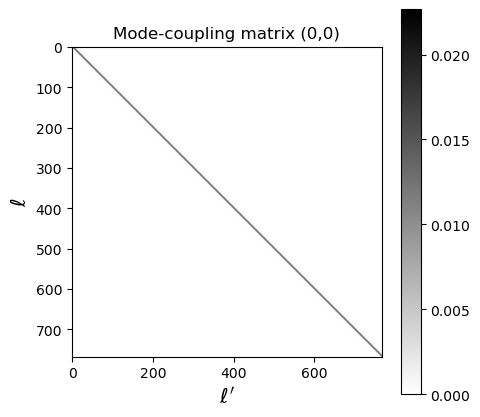

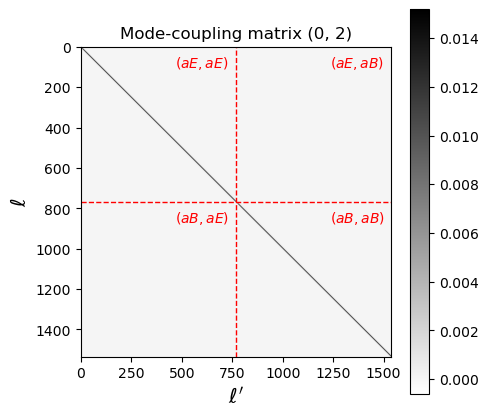

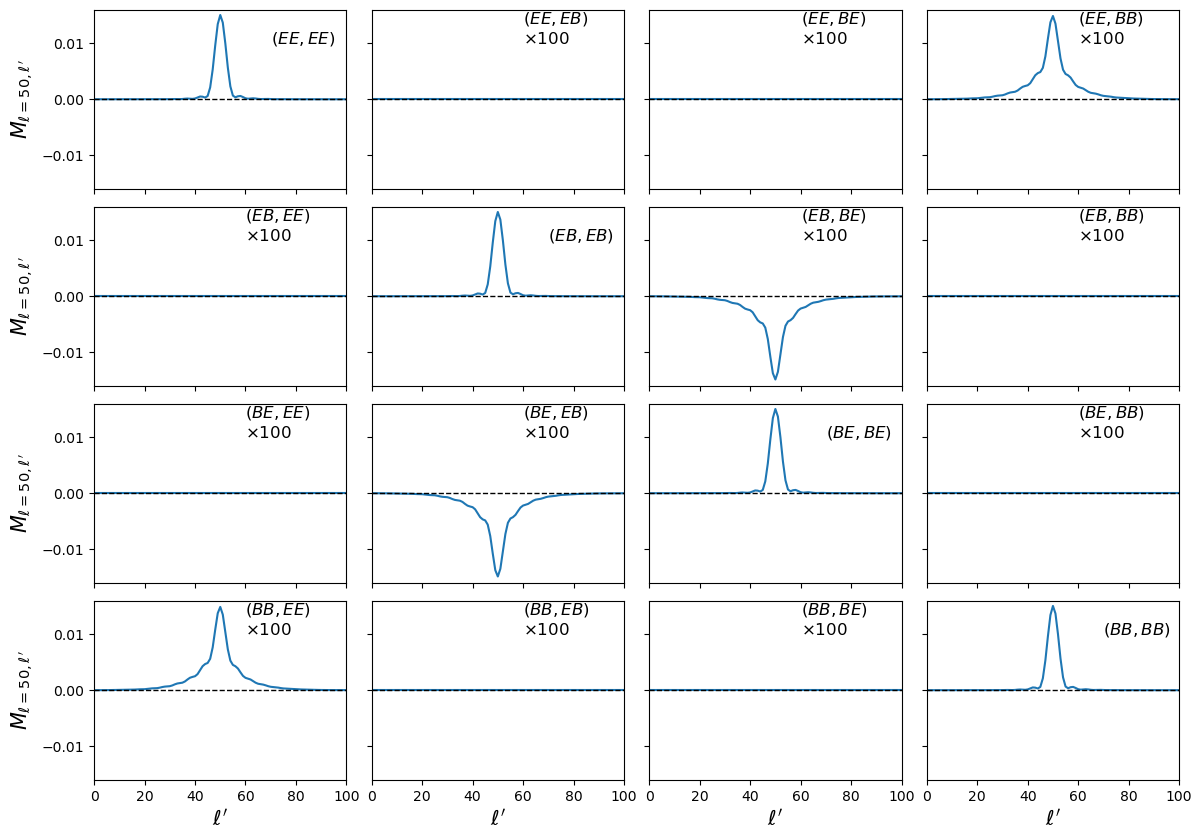

In [4]:
delta_ell = 30
b = nmt.NmtBin.from_nside_linear(nside, nlb=delta_ell)

# Create a NaMaster workspaces for the different spin combinations
w00 = nmt.NmtWorkspace.from_fields(f0, f0, b)
w02 = nmt.NmtWorkspace.from_fields(f0, f2, b)
w22 = nmt.NmtWorkspace.from_fields(f2, f2, b)

# Extract the mode-coupling matrix
mcm00 = w00.get_coupling_matrix()
mcm02 = w02.get_coupling_matrix().reshape([3*nside, 2, 3*nside, 2])
mcm22 = w22.get_coupling_matrix().reshape([3*nside, 4, 3*nside, 4])

# Just reshape these to put them in a more friendly form
mcm02 = np.transpose(mcm02, axes=[1, 0, 3, 2])
mcm22 = np.transpose(mcm22, axes=[1, 0, 3, 2])

# Plot 00 case
plt.figure(figsize=(5, 5))
plt.title('Mode-coupling matrix (0,0)')
plt.imshow(mcm00, cmap='binary')
plt.ylabel("$\\ell$", fontsize=15)
plt.xlabel("$\\ell'$", fontsize=15)
plt.colorbar()

# Plot 02 case
plt.figure(figsize=(5, 5))
plt.title('Mode-coupling matrix (0, 2)')
plt.imshow(mcm02.reshape([2*3*nside, 2*3*nside]), cmap='binary')
plt.ylabel("$\\ell$", fontsize=15)
plt.xlabel("$\\ell'$", fontsize=15)
plt.axvline(3*nside, ls='--', c='r', lw=1)
plt.axhline(3*nside, ls='--', c='r', lw=1)
plt.text(3*nside-300, 100, r'$(aE,aE)$', c='r')
plt.text(6*nside-300, 100, r'$(aE,aB)$', c='r')
plt.text(3*nside-300, 3*nside+100, r'$(aB,aE)$', c='r')
plt.text(6*nside-300, 3*nside+100, r'$(aB,aB)$', c='r')
plt.colorbar()

# Plot 22 case (we plot one specific row, since it's
# easier to see the E->B leakage terms this way).
fig, axes = plt.subplots(4, 4, figsize=(14, 10), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.1, hspace=0.1)
ll = 50
labels = ['EE', 'EB', 'BE', 'BB']
for i in range(4):
    for j in range(4):
        ax = axes[i][j]
        if i!=j:
            ax.plot(ls, mcm22[i][:, j, :][ll]*100)
            ax.text(60, 0.01, f"$({labels[i]},{labels[j]})$\n$\\times 100$", fontsize=12)
        else:
            ax.plot(ls, mcm22[i][:, j, :][ll])
            ax.text(70, 0.01, f"$({labels[i]},{labels[j]})$", fontsize=12)
        ax.set_xlim([0, 100])
        ax.set_ylim([-0.016, 0.016])
        ax.axhline(0, ls='--', c='k', lw=1)
for i in range(4):
    ax = axes[3][i]
    ax.set_xlabel(r"$\ell'$", fontsize=15)
for i in range(4):
    ax = axes[i][0]
    ax.set_ylabel(r"$M_{\ell=50,\ell'}$", fontsize=15)

# As in the scalar case, you can also get bandpower window functions.
# Note that these ones include all potential sources of residual couplings,
# so you need to bear their shape in mind.
for i, spins in enumerate(['00', '02', '22']):
    w = [w00, w02, w22][i]
    Bbl = w.get_bandpower_windows().squeeze()
    print(f"The {spins} bandpower windows have shape {Bbl.shape}")

## 2.4 Unbiased estimator <a class="anchor" id="Ss2.4"></a>
OK, now that we have all the ingredients, let us show that the estimator is unbiased by looking at the average of 100 simulations.

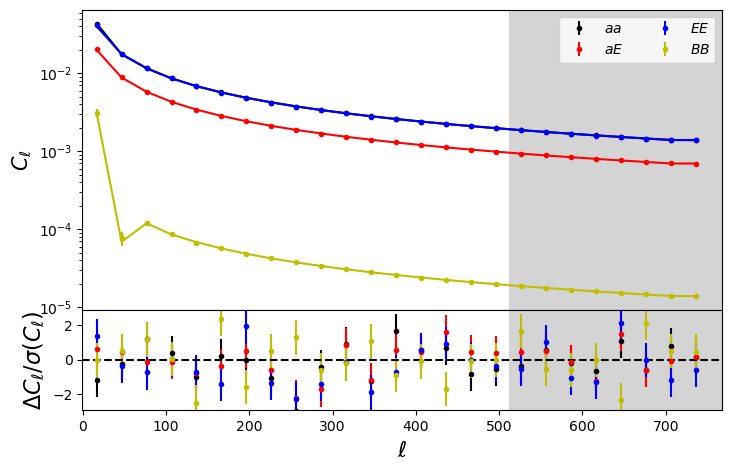

In [5]:
# Run sims
nsims = 100
cls_sims_00 = []
cls_sims_02 = []
cls_sims_22 = []
for i in range(nsims):
    a, Q, U = gen_sim()
    f0 = nmt.NmtField(mask, [a], n_iter=0)
    f2 = nmt.NmtField(mask, [Q, U], n_iter=0)
    cls_sims_00.append(w00.decouple_cell(nmt.compute_coupled_cell(f0, f0)))
    cls_sims_02.append(w02.decouple_cell(nmt.compute_coupled_cell(f0, f2)))
    cls_sims_22.append(w22.decouple_cell(nmt.compute_coupled_cell(f2, f2)))
cls_sims_00 = np.array(cls_sims_00)
cls_sims_02 = np.array(cls_sims_02)
cls_sims_22 = np.array(cls_sims_22)

# Compute sim statistics
cls_mean_00 = np.mean(cls_sims_00, axis=0)
cls_error_00 = np.std(cls_sims_00, axis=0)/np.sqrt(nsims)
cls_mean_02 = np.mean(cls_sims_02, axis=0)
cls_error_02 = np.std(cls_sims_02, axis=0)/np.sqrt(nsims)
cls_mean_22 = np.mean(cls_sims_22, axis=0)
cls_error_22 = np.std(cls_sims_22, axis=0)/np.sqrt(nsims)

# Compute theoretical expectation
cl_th_00 = w00.decouple_cell(w00.couple_cell([cl_aa]))
cl_th_02 = w02.decouple_cell(w02.couple_cell([cl_ae, 0*cl_ae]))
cl_th_22 = w22.decouple_cell(w22.couple_cell([cl_ee, 0*cl_ee, 0*cl_ee, cl_bb]))

# Plot results
leff = b.get_effective_ells()

fig = plt.figure(figsize=(8, 5))
ax = fig.add_axes((.1,.3,.8,.6))
ax.plot(leff, cl_th_00[0], 'k-')
ax.errorbar(leff, cls_mean_00[0], yerr=cls_error_00[0], fmt='k.', label='$aa$')
ax.plot(leff, cl_th_02[0], 'r-')
ax.errorbar(leff, cls_mean_02[0], yerr=cls_error_00[0], fmt='r.', label='$aE$')
ax.plot(leff, cl_th_22[0], 'b-')
ax.errorbar(leff, cls_mean_22[0], yerr=cls_error_22[0], fmt='b.', label='$EE$')
ax.plot(leff, cl_th_22[3], 'y-')
ax.errorbar(leff, cls_mean_22[3], yerr=cls_error_22[3], fmt='y.', label='$BB$')
ax.set_yscale('log')
ax.set_ylabel(r'$C_\ell$', fontsize=15)
ax.set_xticklabels([])
ax.legend(ncol=2)
ax.set_xlim([-0.5, 3*nside])
ax.axvspan(2*nside, 3*nside, facecolor='#AAAAAA', alpha=0.5)

ax = fig.add_axes((.1,.1,.8,.2))
ax.errorbar(leff, (cls_mean_00-cl_th_00)[0]/cls_error_00[0], yerr=np.ones_like(leff), fmt='k.')
ax.errorbar(leff, (cls_mean_02-cl_th_02)[0]/cls_error_02[0], yerr=np.ones_like(leff), fmt='r.')
ax.errorbar(leff, (cls_mean_22-cl_th_22)[0]/cls_error_22[0], yerr=np.ones_like(leff), fmt='b.')
ax.errorbar(leff, (cls_mean_22-cl_th_22)[3]/cls_error_22[3], yerr=np.ones_like(leff), fmt='y.')
ax.axhline(0, c='k', ls='--')
ax.set_ylim([-2.9, 2.9])
ax.set_xlim([-0.5, 3*nside])
ax.axvspan(2*nside, 3*nside, facecolor='#AAAAAA', alpha=0.5)
ax.set_ylabel(r'$\Delta C_\ell/\sigma(C_\ell)$', fontsize=16)
ax.set_xlabel(r'$\ell$', fontsize=16);

## 2.5 Purification <a class="anchor" id="Ss2.5"></a>
Since our fields have significant $E/B$ assymmetry, we should expect $E\rightarrow B$ leakage to contribute significantly to the statistical uncertainties of the $B$-mode power spectrum. This can be mitigated via $B$-mode purification (i.e. the removal of masked $B$-modes that can potentially come from leaked $E$-modes).

Note that, if you are only interested in the $E$-mode power spectrum, or if your fields have roughly the same power in $E$ and $B$, using purification will not help you much. In fact, purifying in these cases may be dangerous! The PCL estimator with purification is only unbiased if the mask is sufficiently smooth and differentiable across the whole sky. Although this can be achieved to some extent using apodization techniques, this is not always straightforward, and it is always a good idea to check what the first two derivatives of your mask look like, and worry if there are any signs of strong numerical instabilities. For this reason, we start our discussion of purification by looking at the mask derivatives.

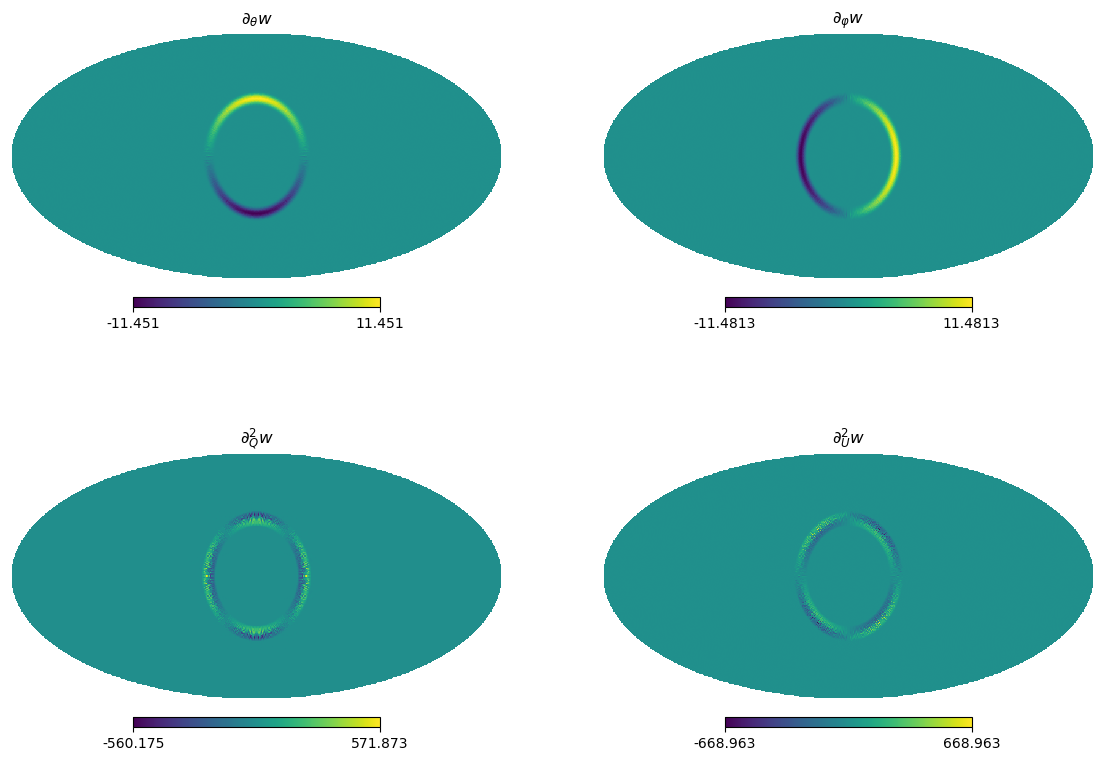

In [6]:
wlm = hp.map2alm(mask)
wlm1 = hp.almxfl(wlm, np.sqrt(ls*(ls+1)))
wlm2 = hp.almxfl(wlm, np.sqrt((ls-1)*ls*(ls+1)*(ls+2)))
mask1 = hp.alm2map_spin([wlm1, 0*wlm1], nside, 1, 3*nside-1)
mask2 = hp.alm2map_spin([wlm2, 0*wlm2], nside, 2, 3*nside-1)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plt.axes(axes[0][0])
hp.mollview(mask1[0], title=r'$\partial_\theta w$', hold=True)
plt.axes(axes[0][1])
hp.mollview(mask1[1], title=r'$\partial_\varphi w$', hold=True)
plt.axes(axes[1][0])
hp.mollview(mask2[0], title=r'$\partial^2_Q w$', hold=True)
plt.axes(axes[1][1])
hp.mollview(mask2[1], title=r'$\partial^2_U w$', hold=True)

If we use purification, we will need to recompute the mode-coupling matrix, since its structure changes. We show how to do this below, and compare the MCMs with and without purification. The most important block is the bottom-left one, which shows the leakage between $EE$ and $BB$. This is now completely suppressed. Note that the top right block (leakage from $BB$ to $EE$) has not changed significantly, since we have not purified the $E$ modes (there's no good reason to do so!).

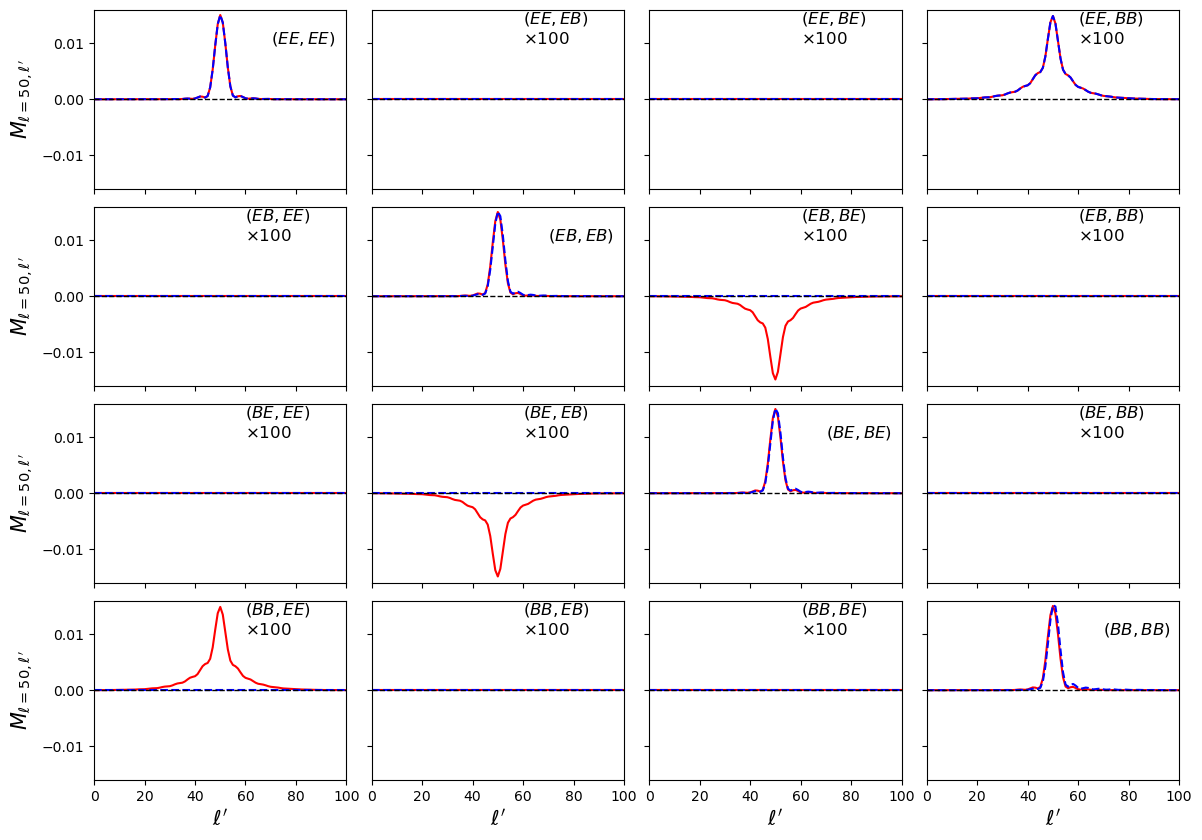

In [7]:
# Activating purification is as simple as passing `purify_b=True`
# when creating a field
# For safety we set to zero all pixels in the input maps where
# the mask is zero.
maskbin = mask > 0
f2p = nmt.NmtField(mask, [mpQ*maskbin, mpU*maskbin], purify_b=True)

# Now compute the MCM
w22p = nmt.NmtWorkspace.from_fields(f2p, f2p, b)
mcm22p = w22p.get_coupling_matrix().reshape([3*nside, 4, 3*nside, 4])
mcm22p = np.transpose(mcm22p, axes=[1, 0, 3, 2])

# Plot 22 case (we plot one specific row, since it's
# easier to see the E->B leakage terms this way).
fig, axes = plt.subplots(4, 4, figsize=(14, 10), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.1, hspace=0.1)
ll = 50
labels = ['EE', 'EB', 'BE', 'BB']
for i in range(4):
    for j in range(4):
        ax = axes[i][j]
        if i!=j:
            ax.plot(ls, mcm22[i][:, j, :][ll]*100, 'r-')
            ax.plot(ls, mcm22p[i][:, j, :][ll]*100, 'b--')
            ax.text(60, 0.01, f"$({labels[i]},{labels[j]})$\n$\\times 100$", fontsize=12)
        else:
            ax.plot(ls, mcm22[i][:, j, :][ll], 'r-')
            ax.plot(ls, mcm22p[i][:, j, :][ll], 'b--')
            ax.text(70, 0.01, f"$({labels[i]},{labels[j]})$", fontsize=12)
        ax.set_xlim([0, 100])
        ax.set_ylim([-0.016, 0.016])
        ax.axhline(0, ls='--', c='k', lw=1)
for i in range(4):
    ax = axes[3][i]
    ax.set_xlabel(r"$\ell'$", fontsize=15)
for i in range(4):
    ax = axes[i][0]
    ax.set_ylabel(r"$M_{\ell=50,\ell'}$", fontsize=15)


Alright, finally, let us check the impact of purification in the power spectrum uncertainties.

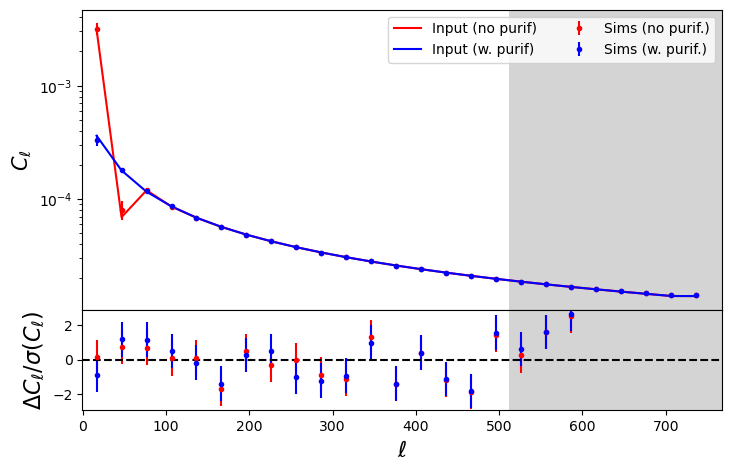

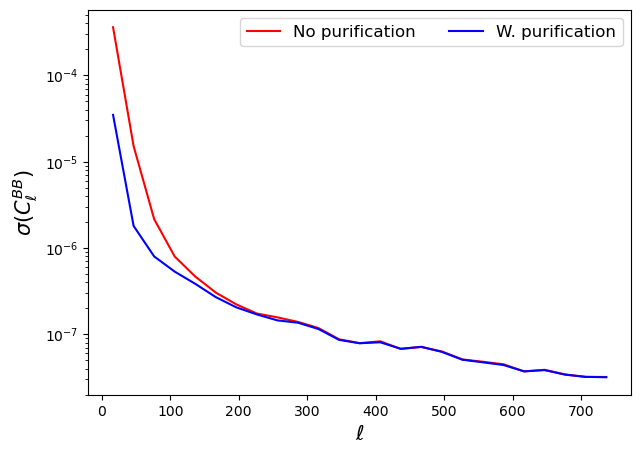

In [8]:
nsims = 100
clbb_sims = []
clbb_sims_pure = []
for i in range(nsims):
    _, Q, U = gen_sim()
    Q *= maskbin
    U *= maskbin
    f = nmt.NmtField(mask, [Q, U])
    fp = nmt.NmtField(mask, [Q, U], purify_b=True)
    clbb_sims.append(w22.decouple_cell(nmt.compute_coupled_cell(f, f))[3])
    clbb_sims_pure.append(w22p.decouple_cell(nmt.compute_coupled_cell(fp, fp))[3])
clbb_sims = np.array(clbb_sims)
clbb_sims_pure = np.array(clbb_sims_pure)

cl_mean = np.mean(clbb_sims, axis=0)
cl_error = np.std(clbb_sims, axis=0)/np.sqrt(nsims)
cl_mean_pure = np.mean(clbb_sims_pure, axis=0)
cl_error_pure = np.std(clbb_sims_pure, axis=0)/np.sqrt(nsims)

cl_th = w22.decouple_cell(w22.couple_cell([cl_ee, 0*cl_ee, 0*cl_ee, cl_bb]))[3]
cl_th_pure = w22p.decouple_cell(w22p.couple_cell([cl_ee, 0*cl_ee, 0*cl_ee, cl_bb]))[3]

# First let's check that the power spectra are unbiased.
# Notice that, after accounting for residual mode coupling,
# the theoretical prediction for C_ell^BB depends on whether
# purification has been carried out.
fig = plt.figure(figsize=(8, 5))
ax = fig.add_axes((.1,.3,.8,.6))
ax.plot(leff, cl_th, 'r-', label='Input (no purif)')
ax.plot(leff, cl_th_pure, 'b-', label='Input (w. purif)')
ax.errorbar(leff, cl_mean, yerr=cl_error, fmt='r.', label='Sims (no purif.)')
ax.errorbar(leff, cl_mean_pure, yerr=cl_error_pure, fmt='b.', label='Sims (w. purif.)')
ax.set_yscale('log')
ax.set_ylabel(r'$C_\ell$', fontsize=15)
ax.set_xticklabels([])
ax.legend(ncol=2)
ax.set_xlim([-0.5, 3*nside])
ax.axvspan(2*nside, 3*nside, facecolor='#AAAAAA', alpha=0.5)

ax = fig.add_axes((.1,.1,.8,.2))
ax.errorbar(leff, (cl_mean-cl_th)/cl_error, yerr=np.ones_like(leff), fmt='r.')
ax.errorbar(leff, (cl_mean_pure-cl_th_pure)/cl_error_pure, yerr=np.ones_like(leff), fmt='b.')
ax.axhline(0, c='k', ls='--')
ax.set_ylim([-2.9, 2.9])
ax.set_xlim([-0.5, 3*nside])
ax.axvspan(2*nside, 3*nside, facecolor='#AAAAAA', alpha=0.5)
ax.set_ylabel(r'$\Delta C_\ell/\sigma(C_\ell)$', fontsize=16)
ax.set_xlabel(r'$\ell$', fontsize=16);

# And now let's look at the error bar
plt.figure(figsize=(7, 5))
plt.plot(leff, cl_error, 'r-', label='No purification')
plt.plot(leff, cl_error_pure, 'b-', label='W. purification')
plt.yscale('log')
plt.xlabel(r'$\ell$', fontsize=15)
plt.ylabel(r'$\sigma(C^{BB}_\ell)$', fontsize=15)
plt.legend(fontsize=12, ncol=2)